# Functional localizer map prediction: human (Supp. Fig. S4-S6)

Loads the outputs already computed and saved by `predict_localizer_maps_human.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg
import seaborn as sns
import neuroboros as nb

OUT_ROOT = "/dartfs/rc/lab/H/HaxbyLab/yuqi/monkey_kingdom_data/functional_maps/human_pairwise_localizer_prediction"

sids = np.load(f"{OUT_ROOT}/sids.npy")
CONTRAST_NAMES = ["face_vs_object", "body_vs_object"]
sids

/dartfs-hpc/rc/home/q/f007d9q/neuroboros/src/neuroboros/io.py:60: UserWarning: DataLad dataset core exists at /dartfs-hpc/rc/home/q/f007d9q/.neuroboros-data/core, but does not have source https://gin.g-node.org/neuroboros/core as a sibling.
  warnings.warn(


array(['sid001123', 'sid001293', 'sid001294', 'sid001678', 'sid001784',
       'sid001830', 'sid001835', 'sid001986', 'sid002015', 'sid002161',
       'sid002180', 'sid002317', 'sid002325', 'sid002406', 'sid002414',
       'sid002435', 'sid002446', 'sid002449', 'sid002454', 'sid002471',
       'sid002499', 'sid002509', 'sid002519', 'sid002570'], dtype='<U9')

## Supp. Fig. S4b: congruent vs. incongruent prediction accuracy, all 24 subjects

procr

congruent mean:

[0.63624502 0.4917206 ]

incongruent mean:

[0.37714114 0.29861987]

ridge

congruent mean:

[0.62039317 0.47281888]

incongruent mean:

[0.35575799 0.27263606]

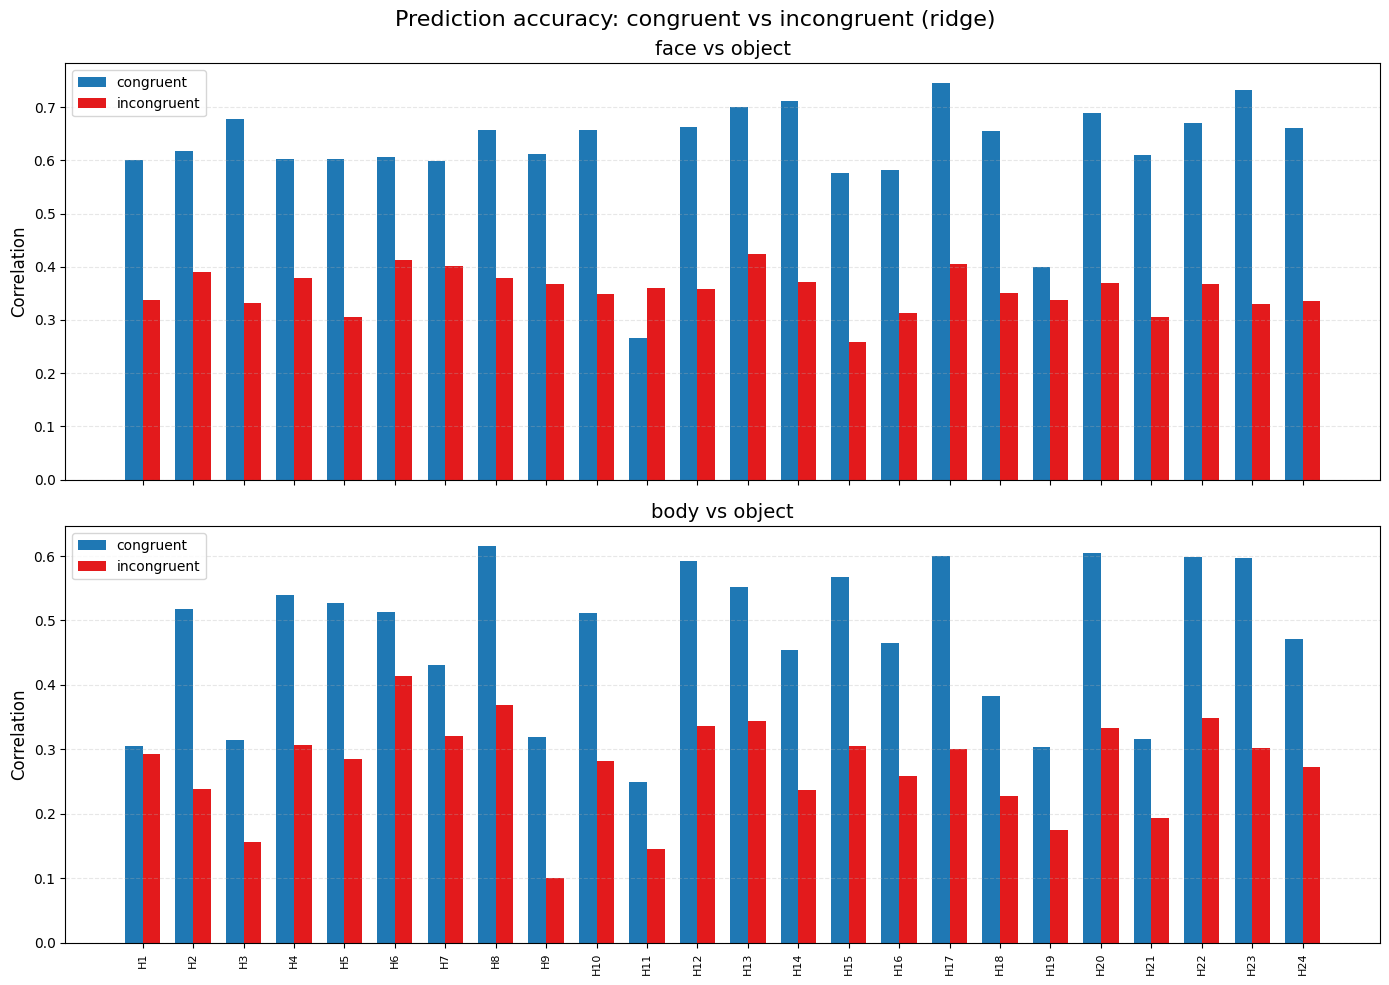

In [2]:
congruent = {a: np.load(f"{OUT_ROOT}/congruent_{a}.npy") for a in ["procr", "ridge"]}
incongruent = {a: np.load(f"{OUT_ROOT}/incongruent_{a}.npy") for a in ["procr", "ridge"]}

for align in ["procr", "ridge"]:
    print(align, "congruent mean:", congruent[align].mean(axis=0), "incongruent mean:", incongruent[align].mean(axis=0))

fig, axes = plt.subplots(len(CONTRAST_NAMES), 1, figsize=(14, 10), sharex=True)
x = np.arange(len(sids))
width = 0.35
labels = [f"H{i + 1}" for i in range(len(sids))]
for c, (cname, ax) in enumerate(zip(CONTRAST_NAMES, axes)):
    ax.bar(x - width / 2, congruent["ridge"][:, c], width, label="congruent", color="#1F78B4")
    ax.bar(x + width / 2, incongruent["ridge"][:, c], width, label="incongruent", color="#E31A1C")
    ax.set_title(cname.replace("_", " "), fontsize=14)
    ax.set_ylabel("Correlation", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=10)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels, rotation=90, fontsize=8)
fig.suptitle("Prediction accuracy: congruent vs incongruent (ridge)", fontsize=16)
fig.tight_layout()
plt.savefig("human_localizer_congruent_vs_incongruent.png", dpi=300, bbox_inches="tight")
plt.show()

## Supp. Fig. S4a / S5 / S6: individual measured vs. predicted maps (z-scored, ridge)

Reproduces the exact plotting convention from the final version of the original notebook
(`hyperalign_localizer_maps_luce_marcel_rank.ipynb`): each map is z-scored per-map, `vmax=4`,
with a hard alpha cutoff below the 95th-percentile `|z|` (`norm.ppf(0.95)`), using the
mako-rocket diverging colormap. Reference subjects for Supp. Fig. S4a are picked the same way
as the original notebook -- the two subjects whose predicted maps best recover their own
measured maps (highest congruent correlation, averaged across both contrasts) -- and cropped to
the lateral view only. Supp. Fig. S5/S6 (all 24 subjects) are cropped to lateral+ventral (medial
dropped) and further restricted to the right hemisphere only, matching the paper.

In [3]:
from scipy.stats import norm
import io
from PIL import Image

nc = 10
_colors = np.concatenate(
    [sns.color_palette("mako", nc)[1:],
     [[0.9, 0.9, 0.9]],
     sns.color_palette("rocket", nc)[1:][::-1]],
    axis=0)
cmap_zscore = mpl.colors.LinearSegmentedColormap.from_list('mako_rocket', _colors)

actual_ts_h = np.load(f"{OUT_ROOT}/actual_ts_all_subjects.npy")  # (n_sids, n_kinds, n_verts)
predicted_ts_ridge_h = np.load(f"{OUT_ROOT}/predicted_ts_ridge.npy")
congruent_ridge = np.load(f"{OUT_ROOT}/congruent_ridge.npy")

vmax = 4
tail_threshold = norm.ppf(0.95)
sids_list = list(sids)
human_name_map = {sid: f"H{i + 1}" for i, sid in enumerate(sids_list)}

mean_congruent = congruent_ridge.mean(axis=1)
best_order = np.argsort(mean_congruent)[::-1]
ref_sids = [sids_list[i] for i in best_order[:2]]
print("Reference human subjects (highest congruent correlation):", [human_name_map[s] for s in ref_sids])

HUMAN_LATERAL_CROP_HEIGHT = 559
HUMAN_LATERAL_VENTRAL_HEIGHT = 1001
HUMAN_RIGHT_HEMI_COLS = (864, 1728)


def zscore_and_alpha_human(vals):
    z = (vals - np.nanmean(vals)) / np.nanstd(vals)
    alpha = np.abs(z) / vmax
    alpha[np.abs(z) < tail_threshold] = 0.0
    return z, alpha


def lateral_view_human(im, label, size=70):
    im.img = im.img.crop((0, 0, im.img.size[0], HUMAN_LATERAL_CROP_HEIGHT))
    return im.title(label, size=size)


def lateral_ventral_view_human(im, label, size=70, right_hemi_only=False):
    img = im.img.crop((0, 0, im.img.size[0], HUMAN_LATERAL_VENTRAL_HEIGHT))
    if right_hemi_only:
        x0, x1 = HUMAN_RIGHT_HEMI_COLS
        img = img.crop((x0, 0, x1, img.size[1]))
    im.img = img
    return im.title(label, size=size)


def contrast_end_labels(contrast_name):
    high_word, low_word = [w.strip().capitalize() for w in contrast_name.split(' vs ')]
    return f"{low_word} > {high_word}", f"{high_word} > {low_word}"


def make_directional_colorbar(vmax, contrast_name, cmap, width_px, dpi=150, end_fontsize=34, height_in=1.4):
    low_label, high_label = contrast_end_labels(contrast_name)
    width_in = width_px / dpi
    fig = plt.figure(figsize=(width_in, height_in), dpi=dpi)
    cb_ax = fig.add_axes([0.15, 0.5, 0.70, 0.20])
    norm_cb = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)
    mpl.colorbar.ColorbarBase(cb_ax, cmap=cmap, norm=norm_cb, orientation='horizontal', ticks=[])
    cb_ax.set_xticks([])
    fig.text(0.15, 0.08, low_label, ha='left', va='bottom', fontsize=end_fontsize, weight='bold')
    fig.text(0.85, 0.08, high_label, ha='right', va='bottom', fontsize=end_fontsize, weight='bold')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', facecolor='white')
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert('RGBA')


def create_subfigure_banner(text, width_px=None, figsize=(14, 1.2), fontsize=28, dpi=300):
    if width_px is not None:
        figsize = (width_px / dpi, figsize[1])
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, facecolor='white')
    ax.axis('off')
    ax.text(0.5, 0.5, text, fontsize=fontsize, weight='bold', va='center', ha='center')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', facecolor='white')
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert('RGBA')

Reference human subjects (highest congruent correlation):

['H17', 'H23']

### Supp. Fig. S4a: two reference human subjects, lateral view only

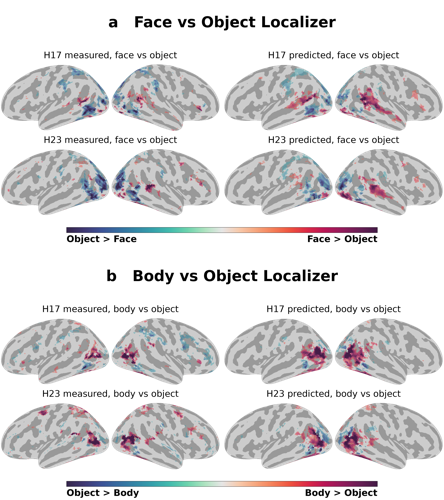

In [4]:
def generate_reference_grid_lateral(c_idx, contrast_name):
    rows = []
    for sid in ref_sids:
        i = sids_list.index(sid)
        label = human_name_map[sid]

        z, alpha = zscore_and_alpha_human(actual_ts_h[i, c_idx])
        im_meas = nb.plot(z, cmap=cmap_zscore, vmax=vmax, vmin=-vmax, alpha=alpha, title=None, colorbar=False)
        im_meas = lateral_view_human(im_meas, f"{label} measured, {contrast_name}")

        z, alpha = zscore_and_alpha_human(predicted_ts_ridge_h[i, c_idx])
        im_pred = nb.plot(z, cmap=cmap_zscore, vmax=vmax, vmin=-vmax, alpha=alpha, title=None, colorbar=False)
        im_pred = lateral_view_human(im_pred, f"{label} predicted, {contrast_name}")

        rows.append(nb.Image.hstack([im_meas, im_pred], padding=20))
    return nb.Image.vstack(rows, padding=30)


grid_a = generate_reference_grid_lateral(CONTRAST_NAMES.index("face_vs_object"), "face vs object")
banner_a = create_subfigure_banner("a   Face vs Object Localizer", width_px=grid_a.img.size[0])
cb_a = make_directional_colorbar(vmax, "face vs object", cmap_zscore, width_px=grid_a.img.size[0])
subfigure_a = nb.Image.vstack([banner_a, grid_a, cb_a], padding=30)

grid_b = generate_reference_grid_lateral(CONTRAST_NAMES.index("body_vs_object"), "body vs object")
banner_b = create_subfigure_banner("b   Body vs Object Localizer", width_px=grid_b.img.size[0])
cb_b = make_directional_colorbar(vmax, "body vs object", cmap_zscore, width_px=grid_b.img.size[0])
subfigure_b = nb.Image.vstack([banner_b, grid_b, cb_b], padding=30)

panel_s4a = nb.Image.vstack([subfigure_a, subfigure_b], padding=60)
panel_s4a.save("human_localizer_supp_s4a_reference_lateral.png")
panel_s4a

### Supp. Fig. S5 / S6: all 24 human subjects, lateral+ventral, right hemisphere only

In [5]:
def generate_all_subjects_grid_lv_rh(c_idx, subjects_per_row=8, caption_size=100):
    meas_ims, pred_ims = [], []
    for i, sid in enumerate(sids_list):
        label = human_name_map[sid]

        z, alpha = zscore_and_alpha_human(actual_ts_h[i, c_idx])
        im_meas = nb.plot(z, cmap=cmap_zscore, vmax=vmax, vmin=-vmax, alpha=alpha, title=None, colorbar=False)
        meas_ims.append(lateral_ventral_view_human(im_meas, f"{label} measured", size=caption_size, right_hemi_only=True))

        z, alpha = zscore_and_alpha_human(predicted_ts_ridge_h[i, c_idx])
        im_pred = nb.plot(z, cmap=cmap_zscore, vmax=vmax, vmin=-vmax, alpha=alpha, title=None, colorbar=False)
        pred_ims.append(lateral_ventral_view_human(im_pred, f"{label} predicted", size=caption_size, right_hemi_only=True))

    blocks = []
    for i in range(0, len(meas_ims), subjects_per_row):
        blocks.append(nb.Image.vstack([
            nb.Image.hstack(meas_ims[i:i + subjects_per_row], padding=20),
            nb.Image.hstack(pred_ims[i:i + subjects_per_row], padding=20),
        ], padding=20))
    return nb.Image.vstack(blocks, padding=40)


for cname in CONTRAST_NAMES:
    c_idx = CONTRAST_NAMES.index(cname)
    grid = generate_all_subjects_grid_lv_rh(c_idx)
    cname_title = cname.replace("_", " ").replace("face", "Face").replace("body", "Body").replace("object", "Object")
    banner = create_subfigure_banner(f"{cname_title} Localizer (all subjects, right hemisphere)", width_px=grid.img.size[0], fontsize=48)
    cb = make_directional_colorbar(vmax, cname.replace("_", " "), cmap_zscore, width_px=grid.img.size[0])
    panel = nb.Image.vstack([banner, grid, cb], padding=30)
    panel.max_height = 4000
    panel.save(f"human_localizer_all_subjects_lateral_ventral_RH_{cname}.png")
    print(cname, "-- saved human_localizer_all_subjects_lateral_ventral_RH_" + cname + ".png")

face_vs_object

-- saved human_localizer_all_subjects_lateral_ventral_RH_face_vs_object.png

body_vs_object

-- saved human_localizer_all_subjects_lateral_ventral_RH_body_vs_object.png